In [1]:
import os 
import sys
from pathlib import Path

# 1. Setup Configuration
repo_root = Path(".").resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

config_path = repo_root / ".dcbench" / "dcbench-config.yaml"
os.makedirs(repo_root / ".dcbench", exist_ok=True)

local_dir = repo_root / ".dcbench"

config_content = f"""local_dir: {local_dir}
public_bucket_name: dcbench
hidden_bucket_name: dcbench-hidden
celeba_dir: {local_dir / 'datasets' / 'celeba'}
imagenet_dir: {local_dir / 'datasets' / 'imagenet'}
"""

with open(config_path, "w") as f:
    f.write(config_content)

os.environ["DCBENCH_CONFIG"] = str(config_path)

# 2. Add Domino to Path
domino_path = (repo_root.parent.parent / "sdbench" / "postprocessors").resolve()
if str(domino_path) not in sys.path:
    sys.path.insert(0, str(domino_path))

import dcbench
import meerkat as mk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as skmetrics
from domino import DominoSlicer
from dcbench.tasks.slice_discovery.run import run_sdms

task = dcbench.tasks["slice_discovery"]

# `dcbench`: Slice Discovery Categories Walkthrough

Slice discovery is essential because models often fail on specific subgroups (*slices*) even when overall accuracy is high. These failure modes typically fall into three categories: **Correlation**, **Rareness**, and **Label Noise**.

In `dcbench`, we evaluate if a discovery algorithm can find hidden "Ground Truth" slices that represent these model blind spots.

## 1. Correlation Slices
Correlation slices occur when a model relies on a spurious correlation with a sensitive attribute (e.g., gender, age) to make predictions. 

### Case Study: Lipstick vs. Age
In CelebA, the target class is **'wearing_lipstick'**. The model often learns to associate lipstick with gender or age rather than the visual presence of lipstick itself.

/home/azureuser/.local/lib/python3.10/site-packages/meerkat/ml/__init__.py:7: ExperimentalWarning: The `meerkat.ml` module is experimental and has limited test coverage. Proceed with caution.
  warnings.warn(


Dataset size (n): 6221
Total hidden slices (k): 2
Target: wearing_lipstick
Overall Accuracy: 90.68%
- Slice S_0 ('wearing_lipstick=0_young=1'): Size=1205, Accuracy=75.93%
- Slice S_1 ('wearing_lipstick=1_young=0'): Size=1167, Accuracy=98.11%


,id (PandasSeriesColumn),target (NumpyArrayColumn),probs (ClassificationOutputColumn),split_x (PandasSeriesColumn),image_x (ImageColumn),slices (NumpyArrayColumn),image_y (ImageColumn),split_y (PandasSeriesColumn)
0,143706.jpg,0,"[tensor(0.1603), tensor(0.8397)]",test,,"[True, False]",,train
1,084131.jpg,0,"[tensor(0.9760), tensor(0.0240)]",test,,"[True, False]",,train
2,134169.jpg,0,"[tensor(0.3402), tensor(0.6598)]",test,,"[True, False]",,train

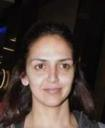
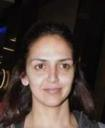
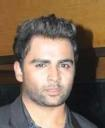
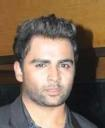
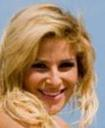
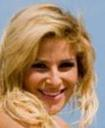

In [2]:
# Load correlation problem p_72776
problem = task.problems["p_72776"]
data = problem.merge(split="test", slices=True)
base_dataset = problem.artifacts["base_dataset"].load()
merged = mk.merge(data, base_dataset, on="id")

y_true = merged["target"].to_numpy()
y_prob = merged["probs"].to_numpy()

# Model predictions (y_pred)
# Note: 'probs' is often (n_samples, 2). We take the probability of the positive class (index 1).
if y_prob.ndim == 2 and y_prob.shape[1] == 2:
    y_pred = (y_prob[:, 1] > 0.5).astype(int)
else:
    y_pred = (y_prob > 0.5).astype(int)

is_correct = (y_pred == y_true)

# Variables from problem formulation
n = len(merged)
slices = merged["slices"].to_numpy()
k = slices.shape[1]
print(f"Dataset size (n): {n}")
print(f"Total hidden slices (k): {k}")
print(f"Target: {problem.attributes['target_name']}")
print(f"Overall Accuracy: {is_correct.mean():.2%}")

for i, name in enumerate(problem.attributes["slice_names"]):
    mask = slices[:, i] == 1
    print(f"- Slice S_{i} ('{name}'): Size={mask.sum()}, Accuracy={is_correct[mask].mean():.2%}")

# Visualize the 'wearing_lipstick=0_young=1' slice (Young men/unpainted faces)
slice_0_mask = slices[:, 0] == 1
merged.lz[slice_0_mask].head(3)

## 2. Rareness Slices
Rareness slices consist of classes or subgroups that are naturally infrequent in the training data.

### Case Study: Food vs. Menu
In this ImageNet example (`p_118818`), the target class is **'food.n.01'**, and the hidden slice is **'menu.n.02'**. Menus often appear in food-related contexts but are visually distinct from the food itself, making them a rare and challenging subgroup for a general 'food' classifier.

Dataset size (n): 6057
Total hidden slices (k): 1
Target: food.n.01
Overall Accuracy: 82.38%
- Slice S_0 ('menu.n.02'): Size=103, Accuracy=68.93%


,id (PandasSeriesColumn),target (NumpyArrayColumn),probs (ClassificationOutputColumn),split (PandasSeriesColumn),image_x (ImageColumn),name_x (PandasSeriesColumn),synset_x (PandasSeriesColumn),slices (NumpyArrayColumn),image_y (ImageColumn),name_y (PandasSeriesColumn),synset_y (PandasSeriesColumn)
0,n07565083_8506,1,"[tensor(0.7714), tensor(0.2286)]",test,,menu,n07565083,[1.0],,menu,n07565083
1,n07565083_3030,1,"[tensor(0.0478), tensor(0.9522)]",test,,menu,n07565083,[1.0],,menu,n07565083
2,ILSVRC2012_val_00045664,1,"[tensor(0.2066), tensor(0.7934)]",test,,menu,n07565083,[1.0],,menu,n07565083

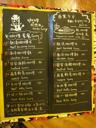
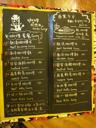
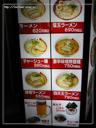
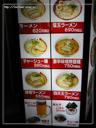
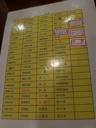
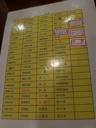

In [3]:
# Load rareness problem p_118818
problem = task.problems["p_118818"]
data = problem.merge(split="test", slices=True)
base_dataset = problem.artifacts["base_dataset"].load()
merged = mk.merge(data, base_dataset, on="id")

y_true = merged["target"].to_numpy()
y_prob = merged["probs"].to_numpy()

# Model predictions (y_pred)
# Note: 'probs' is often (n_samples, 2). We take the probability of the positive class (index 1).
if y_prob.ndim == 2 and y_prob.shape[1] == 2:
    y_pred = (y_prob[:, 1] > 0.5).astype(int)
else:
    y_pred = (y_prob > 0.5).astype(int)

is_correct = (y_pred == y_true)

# Variables from problem formulation
n = len(merged)
slices = merged["slices"].to_numpy()
k = slices.shape[1]
print(f"Dataset size (n): {n}")
print(f"Total hidden slices (k): {k}")
print(f"Target: {problem.attributes['target_name']}")
print(f"Overall Accuracy: {is_correct.mean():.2%}")

for i, name in enumerate(problem.attributes["slice_names"]):
    mask = slices[:, i] == 1
    print(f"- Slice S_{i} ('{name}'): Size={mask.sum()}, Accuracy={is_correct[mask].mean():.2%}")

# Visualize images from the 'menu' slice
rare_slice_mask = slices[:, 0] == 1
merged.lz[rare_slice_mask].head(3)

## 3. Label Noise Slices
Label noise slices occur when the ground truth labels themselves are incorrect, ambiguous, or inconsistently applied.

### Case Study: House Cat vs. Cougar
In this example (`p_122446`), the target class is **'cat.n.01'** (house cats), and the hidden slice is **'cougar.n.01'**. The model struggles because cougars are visually similar to house cats but belong to a different semantic category, and labeling in ImageNet may be inconsistent here.

Dataset size (n): 6004
Total hidden slices (k): 1
Target: cat.n.01
Overall Accuracy: 83.36%
- Slice S_0 ('cougar.n.01'): Size=263, Accuracy=57.03%


,id (PandasSeriesColumn),target (NumpyArrayColumn),probs (ClassificationOutputColumn),split (PandasSeriesColumn),image_x (ImageColumn),name_x (PandasSeriesColumn),synset_x (PandasSeriesColumn),slices (NumpyArrayColumn),image_y (ImageColumn),name_y (PandasSeriesColumn),synset_y (PandasSeriesColumn)
0,n02125311_20134,1,"[tensor(0.3328), tensor(0.6672)]",test,,"cougar, puma, catamount, mountain lion, painter, panther, Felis concolor",n02125311,[1.0],,"cougar, puma, catamount, mountain lion, painter, panther, Felis concolor",n02125311
1,n02125311_14079,1,"[tensor(0.5452), tensor(0.4548)]",test,,"cougar, puma, catamount, mountain lion, painter, panther, Felis concolor",n02125311,[1.0],,"cougar, puma, catamount, mountain lion, painter, panther, Felis concolor",n02125311
2,n02125311_38939,1,"[tensor(0.0846), tensor(0.9154)]",test,,"cougar, puma, catamount, mountain lion, painter, panther, Felis concolor",n02125311,[1.0],,"cougar, puma, catamount, mountain lion, painter, panther, Felis concolor",n02125311

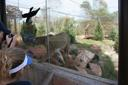
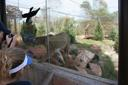
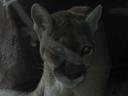
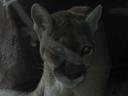
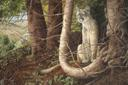
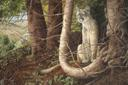

In [4]:
# Load noisy label problem p_122446
problem = task.problems["p_122446"]
data = problem.merge(split="test", slices=True)
base_dataset = problem.artifacts["base_dataset"].load()
merged = mk.merge(data, base_dataset, on="id")

y_true = merged["target"].to_numpy()
y_prob = merged["probs"].to_numpy()

# Model predictions (y_pred)
# Note: 'probs' is often (n_samples, 2). We take the probability of the positive class (index 1).
if y_prob.ndim == 2 and y_prob.shape[1] == 2:
    y_pred = (y_prob[:, 1] > 0.5).astype(int)
else:
    y_pred = (y_prob > 0.5).astype(int)

is_correct = (y_pred == y_true)

# Variables from problem formulation
n = len(merged)
slices = merged["slices"].to_numpy()
k = slices.shape[1]
print(f"Dataset size (n): {n}")
print(f"Total hidden slices (k): {k}")
print(f"Target: {problem.attributes['target_name']}")
print(f"Overall Accuracy: {is_correct.mean():.2%}")

for i, name in enumerate(problem.attributes["slice_names"]):
    mask = slices[:, i] == 1
    print(f"- Slice S_{i} ('{name}'): Size={mask.sum()}, Accuracy={is_correct[mask].mean():.2%}")

# Visualize Cougars (the noisy slice)
noisy_slice_mask = slices[:, 0] == 1
merged.lz[noisy_slice_mask].head(3)

## Summary of Task Types

| Category | Data Set | Characteristics |
| :--- | :--- | :--- |
| **Correlation** | CelebA | Performance drops driven by wrong correlations of attributes (gender, age). |
| **Rareness** | ImageNet | Low accuracy on infrequent classes. |
| **Label Noise** | ImageNet | Apparent errors caused by mislabeling or class ambiguity. |

These categories allow us to benchmark how well a solver can identify diverse types of model failure modes.

## 4. Discovering Slices with `DominoSlicer`

`DominoSlicer` is a slice discovery algorithm that identifies underperforming subgroups by jointly modeling three key signals:
1. **Input Embeddings ($Z$):** High-dimensional feature representations (e.g., from a pre-trained model like CLIP).
2. **Ground Truth Labels ($Y$):** The actual class labels for each sample.
3. **Model Predictions ($\\hat{Y}$):** The predicted probabilities or labels from the model being evaluated.

By finding clusters (slices) that are homogeneous in their error patterns (e.g., high concentration of false positives), `DominoSlicer` helps developers pinpoint specific failure modes.

### Hyperparameter Configurations

The behavior of `DominoSlicer` can be tuned using several key hyperparameters:

| Hyperparameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `n_slices` | `int` | `5` | The number of top underperforming slices to return. |
| `n_mixture_components` | `int` | `25` | The total number of clusters (mixture components) to fit. The algorithm then selects the most problematic ones as slices. |
| `y_log_likelihood_weight` | `float` | `1.0` | Weight ($\gamma$) for the ground truth labels. Increasing this makes the slices more homogeneous with respect to the actual class. |
| `y_hat_log_likelihood_weight` | `float` | `1.0` | Weight ($\hat{\gamma}$) for the model predictions. Increasing this focuses the slices on specific types of model errors (e.g., false positives). |
| `n_pca_components` | `int` | `128` | Number of PCA components to reduce embedding dimensionality before clustering. |
| `init_params` | `str` | `"kmeans"` | Initialization method. |

In [5]:
problem = task.problems["p_72776"]
problem

SliceDiscoveryProblem(artifacts={'activations': 'DataPanelArtifact', 'base_dataset': 'VisionDatasetArtifact', 'clip': 'DataPanelArtifact', 'model': 'ModelArtifact', 'test_predictions': 'DataPanelArtifact', 'test_slices': 'DataPanelArtifact', 'val_predictions': 'DataPanelArtifact'}, attributes={'alpha': 0.2, 'dataset': 'celeba', 'n_pred_slices': 5, 'slice_category': 'correlation', 'slice_names': ['wearing_lipstick=0_young=1', 'wearing_lipstick=1_young=0'], 'target_name': 'wearing_lipstick'})

In [6]:
# In dcbench, we can use the 'run_sdms' helper to evaluate a slicer on multiple problems
# For this illustration, we'll run it on the correlation problem (p_72776)
problem = task.problems["p_72776"]
solutions, metrics_df = run_sdms(
    problems=[problem],
    slicer_class=DominoSlicer,
    slicer_config={
        "y_log_likelihood_weight": 10.0,
        "y_hat_log_likelihood_weight": 10.0,
    },
    encoder="clip",
    num_workers=10
)

2026-03-11 15:26:33,388	INFO worker.py:2013 -- Started a local Ray instance.
/home/azureuser/.local/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

(_run_sdms pid=8176) /home/azureuser/.local/lib/python3.10/site-packages/meerkat/ml/__init__.py:7: ExperimentalWarning: The `meerkat.ml` module is experimental and has limited test coverage. Proceed with caution.
(_run_sdms pid=8176)   warnings.warn(
 37%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                                                                                                                                                                                                                                                                                                                                                    

### Understanding `metrics_df`

The `metrics_df` table provides a quantitative evaluation of how well the discovered slices match the hidden "Ground Truth" slices. For each ground-truth slice, the best-matching predicted slice is identified (using Average Precision) and various metrics are reported:

| Field | Description | Computation |
| :--- | :--- | :--- |
| **`target_slice_name`** | The name of the hidden ground-truth slice. | From problem attributes. |
| **`pred_slice_idx`** | The index of the predicted slice that best matches the target. | Best match across all $2 \times N$ predicted slices (includes complements). |
| **`average_precision`** | Summarizes the precision-recall curve. | `skmetrics.average_precision_score` using predicted slice probabilities. |
| **`precision-at-k`** | Precision among the top $k$ samples ranked by the slice probability. | Percentage of the top $k$ predicted samples that are actually in the ground-truth slice. |
| **`precision`** | Standard precision for the binary prediction. | $TP / (TP + FP)$ |
| **`recall`** | Standard recall for the binary prediction. | $TP / (TP + FN)$ |
| **`f1_score`** | Harmonic mean of precision and recall. | $2 \cdot \frac{precision \cdot recall}{precision + recall}$ |
| **`support`** | The size of the ground-truth slice. | Number of samples where the ground-truth slice mask is 1. |

**Note on `pred_slice_idx`:**  
`dcbench` evaluates both the predicted slices and their complements (e.g., "Not in Slice X"). If a predicted slice's complement matches a target slice better, it will be selected, which is why the index might exceed the requested `n_slices`.

In [7]:
metrics_df

,target_slice_idx,target_slice_name,pred_slice_idx,average_precision,precision-at-10,precision-at-25,precision,recall,f1_score,support,solution_id,problem_id
0,0,wearing_lipstick=0_young=1,0,0.462114,0.6,0.56,0.422222,0.441494,0.431643,None,077816fcc235419bb836d66dced136d8,p_72776
1,1,wearing_lipstick=1_young=0,5,0.373201,0.4,0.24,0.235235,1.000000,0.380875,None,077816fcc235419bb836d66dced136d8,p_72776


### Understanding `solutions`

--- Solution Metadata ---
Problem ID:    p_72776
Slicer Class:  MixtureSlicer
Configuration: {'y_log_likelihood_weight': 10.0, 'y_hat_log_likelihood_weight': 10.0}

Discovered 5 potential failure modes (slices).
Displaying the top 3 examples for each discovered slice:

### Discovered Slice 0 (Size: 1260) ###


,id (PandasSeriesColumn),slice_preds (NumpyArrayColumn),slice_probs (NumpyArrayColumn),target (NumpyArrayColumn),probs (ClassificationOutputColumn),split (PandasSeriesColumn),image (ImageColumn),slices (NumpyArrayColumn)
0,143706.jpg,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",0,"[tensor(0.1603), tensor(0.8397)]",test,,"[True, False]"

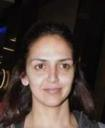

### Discovered Slice 1 (Size: 918) ###


,id (PandasSeriesColumn),slice_preds (NumpyArrayColumn),slice_probs (NumpyArrayColumn),target (NumpyArrayColumn),probs (ClassificationOutputColumn),split (PandasSeriesColumn),image (ImageColumn),slices (NumpyArrayColumn)
0,174339.jpg,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",0,"[tensor(0.9841), tensor(0.0159)]",test,,"[False, False]"

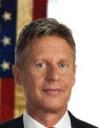

### Discovered Slice 2 (Size: 3003) ###


,id (PandasSeriesColumn),slice_preds (NumpyArrayColumn),slice_probs (NumpyArrayColumn),target (NumpyArrayColumn),probs (ClassificationOutputColumn),split (PandasSeriesColumn),image (ImageColumn),slices (NumpyArrayColumn)
0,016478.jpg,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",1,"[tensor(0.3041), tensor(0.6959)]",test,,"[False, False]"

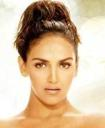

### Discovered Slice 3 (Size: 732) ###


,id (PandasSeriesColumn),slice_preds (NumpyArrayColumn),slice_probs (NumpyArrayColumn),target (NumpyArrayColumn),probs (ClassificationOutputColumn),split (PandasSeriesColumn),image (ImageColumn),slices (NumpyArrayColumn)
0,176918.jpg,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",0,"[tensor(0.9632), tensor(0.0368)]",test,,"[False, False]"

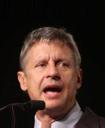

### Discovered Slice 4 (Size: 308) ###


,id (PandasSeriesColumn),slice_preds (NumpyArrayColumn),slice_probs (NumpyArrayColumn),target (NumpyArrayColumn),probs (ClassificationOutputColumn),split (PandasSeriesColumn),image (ImageColumn),slices (NumpyArrayColumn)
0,031935.jpg,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",0,"[tensor(0.9899), tensor(0.0101)]",test,,"[True, False]"

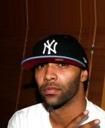

In [11]:
sol = solutions[0]
print("--- Solution Metadata ---")
print(f"Problem ID:    {sol.problem_id}")
print(f"Slicer Class:  {sol.slicer_class.__name__}")
print(f"Configuration: {sol.slicer_config}")

# 2. Merge the predicted slices with the base dataset and ground truth
# This returns a Meerkat DataPanel containing everything we need for visualization
merged_sol = sol.merge()

# 3. Explore the discovered slices
# The 'slice_preds' column contains a binary matrix where each column is a discovered slice
pred_matrix = merged_sol["slice_preds"].to_numpy()
n_slices = pred_matrix.shape[1]

print(f"\nDiscovered {n_slices} potential failure modes (slices).")
print("Displaying the top 3 examples for each discovered slice:\n")

for i in range(n_slices):
    mask = pred_matrix[:, i] == 1
    if mask.any():
        print(f"### Discovered Slice {i} (Size: {mask.sum()}) ###")
        # Use .lz (lazy) indexing to avoid loading all images into memory at once
        display(merged_sol.lz[mask].head(1))
    else:
        print(f"### Discovered Slice {i} is empty ###")